# 📊 TUGAS 2A — Exploratory Data Analysis Review Aplikasi Honest

---

**Dataset:** `cleandata.csv` — Review aplikasi Honest (Kartu Kredit Digital)  
**Kolom:** `score`, `content`, `text_final`, `reviewCreatedVersion`

## 📚 Tujuan Pembelajaran

1. Memahami struktur dan karakteristik dataset review aplikasi Honest
2. Melakukan eksplorasi data secara menyeluruh (missing values, duplikasi, distribusi)
3. Menganalisis distribusi rating, panjang review, dan versi aplikasi
4. Membuat visualisasi informatif untuk mendukung pemahaman data
5. Menarik insight dan kesimpulan dari hasil eksplorasi

## 1) 📦 Install & Import Library

Menginstall dan mengimport library yang diperlukan untuk EDA.

In [24]:
%pip install matplotlib seaborn wordcloud Sastrawi -q

Note: you may need to restart the kernel to use updated packages.


In [25]:
import re
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter
import warnings
warnings.filterwarnings('ignore')

sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 12

print("✅ Semua library berhasil diimport!")

✅ Semua library berhasil diimport!


## 2) 📂 Load Dataset

Memuat dataset `cleandata.csv` yang berisi review aplikasi Honest yang sudah melalui tahap preprocessing.

In [26]:
df = pd.read_csv('cleandata.csv')
print(f"Dataset berhasil dimuat!")
print(f"Jumlah baris : {df.shape[0]:,}")
print(f"Jumlah kolom : {df.shape[1]}")
print("=" * 60)
df.head()

Dataset berhasil dimuat!
Jumlah baris : 39,164
Jumlah kolom : 4


,score,content,text_final,reviewCreatedVersion
0,5,ini adalah pertama kali saya menggunakan kartu...,kali kartu kredit cocok anak muda update alam ...,3.831.0
1,5,"pengajuan berhasil, pelayanan utk CS atas nama...",hasil layan cs nama sangat sopan jelas sangat ...,3.833.1
2,5,Pengajuan cepat dan aman..,cepat aman,3.833.1
3,5,cs Ridwan terbaik,cs baik,3.833.1
4,5,penjelasan yang baik oleh mba rima,jelas baik,3.833.1


## 3) 🔍 Data Overview

Melihat informasi umum dataset: tipe data, nilai unik, dan statistik deskriptif.

In [27]:
print("📌 Info Dataset:")
print("=" * 60)
print(f"Shape: {df.shape}")
print(f"\nTipe Data:")
print(df.dtypes)
print(f"\n📌 Jumlah Nilai Unik per Kolom:")
for col in df.columns:
    print(f"  {col}: {df[col].nunique():,}")

📌 Info Dataset:
Shape: (39164, 4)

Tipe Data:
score                   int64
content                   str
text_final                str
reviewCreatedVersion      str
dtype: object

📌 Jumlah Nilai Unik per Kolom:
  score: 5
  content: 37,341
  text_final: 34,102
  reviewCreatedVersion: 171


In [28]:
print("📌 Statistik Deskriptif (Numerik):")
print("=" * 60)
df.describe()

📌 Statistik Deskriptif (Numerik):


,score
count,39164.000000
mean,4.615131
std,1.115246
min,1.000000
25%,5.000000
50%,5.000000
75%,5.000000
max,5.000000


In [29]:
print("📌 Sample Data Acak (5 baris):")
print("=" * 60)
df.sample(5, random_state=42)

📌 Sample Data Acak (5 baris):


,score,content,text_final,reviewCreatedVersion
2541,5,"mantapp approve nya tinggi, Cs ramah banget (f...",mantapp approve cs ramah banget rekomendasi sa...,3.753.0
14794,5,"Siap, mantap, thx Mas Badal 😁",mantap terima kasih,3.296.2
37154,5,Limitnya lumayan untuk urgent apalagi pada saa...,limit lumayan urgent thank you card,2.846.2
853,5,pengajuan mudah dan cepat. approval mudah,mudah cepat approval mudah,NaN
22859,5,Rekomen honest cs ramah memberikan informasi t...,rekomen cs ramah informasi kait,3.72.0


## 4) ❓ Missing Values

Mengecek kelengkapan data. Kolom `reviewCreatedVersion` memiliki **5,063 missing values (12.93%)** — kolom lainnya lengkap.

📌 Missing Values:
                      Jumlah Null  Persentase (%)
score                           0            0.00
content                         0            0.00
text_final                      0            0.00
reviewCreatedVersion         5063           12.93


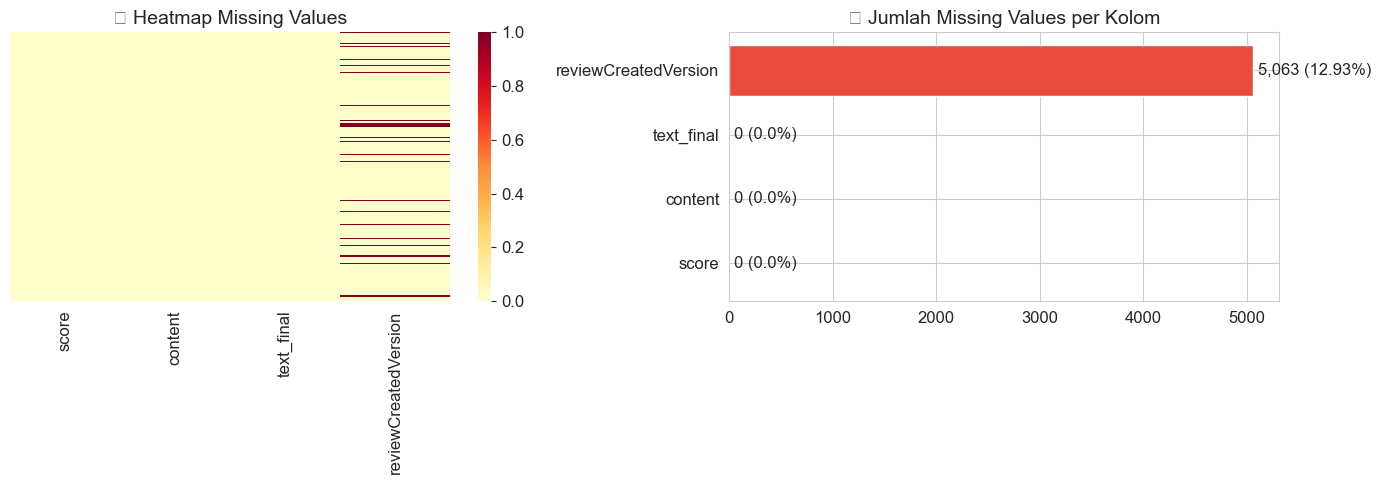

In [30]:
null_counts = df.isnull().sum()
null_pct = (df.isnull().sum() / len(df) * 100).round(2)
null_df = pd.DataFrame({'Jumlah Null': null_counts, 'Persentase (%)': null_pct})
print("📌 Missing Values:")
print("=" * 60)
print(null_df)

# Visualisasi
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Heatmap
sns.heatmap(df.isnull(), cbar=True, yticklabels=False, cmap='YlOrRd', ax=axes[0])
axes[0].set_title('📊 Heatmap Missing Values', fontsize=14)

# Bar chart
colors = ['#e74c3c' if v > 0 else '#2ecc71' for v in null_counts.values]
axes[1].barh(null_counts.index, null_counts.values, color=colors)
axes[1].set_title('📊 Jumlah Missing Values per Kolom', fontsize=14)
for i, v in enumerate(null_counts.values):
    axes[1].text(v + 50, i, f'{v:,} ({null_pct.iloc[i]}%)', va='center')

plt.tight_layout()
plt.show()

## 5) 🔄 Deteksi & Penanganan Duplikasi

Memeriksa apakah ada baris duplikat dalam dataset. Duplikat dihapus untuk memastikan setiap review dihitung satu kali.

In [31]:
dup_count = df.duplicated().sum()
print(f"📌 Jumlah baris duplikat: {dup_count:,}")
print(f"📌 Persentase duplikat: {dup_count / len(df) * 100:.2f}%")

if dup_count > 0:
    print(f"\n🔹 Contoh baris duplikat:")
    print(df[df.duplicated(keep=False)].head(6))
    
    df_clean = df.drop_duplicates().reset_index(drop=True)
    print(f"\n✅ Setelah hapus duplikat: {len(df_clean):,} baris (dari {len(df):,})")
else:
    df_clean = df.copy()
    print("✅ Tidak ada duplikat!")

📌 Jumlah baris duplikat: 455
📌 Persentase duplikat: 1.16%

🔹 Contoh baris duplikat:
     score          content    text_final reviewCreatedVersion
59       5     bagus sekali  bagus sekali                  NaN
77       5  pengajuan mudah         mudah                  NaN
167      5             baik          baik              3.825.1
236      5             baik          baik              3.825.1
270      5             baik          baik              3.779.6
275      5             baik          baik              3.825.1

✅ Setelah hapus duplikat: 38,709 baris (dari 39,164)


## 6) ⭐ Distribusi Score (Rating)

Menganalisis sebaran rating yang diberikan pengguna. Dataset ini sangat **positif-skewed** — hampir 88% review memberikan score 5.

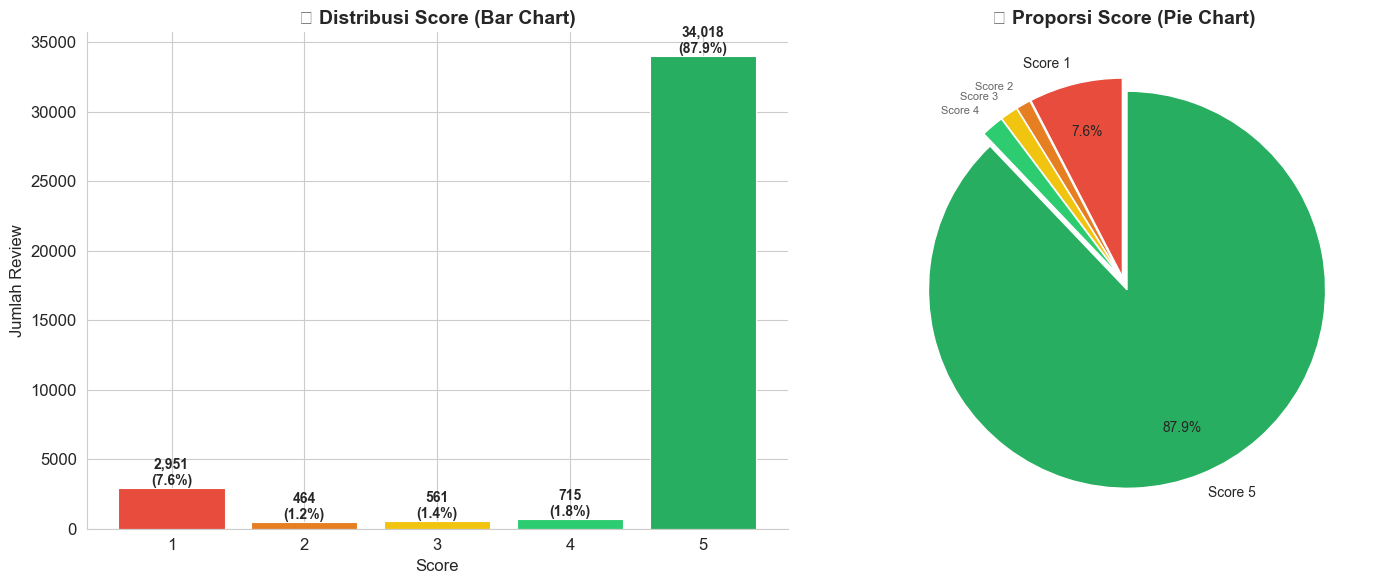

📌 Total Review (setelah dedup): 38,709
📌 Rata-rata Score : 4.61
📌 Median Score    : 5.0
📌 Modus Score     : 5

🔹 Score 5 mendominasi 87.9% dari seluruh review
🔹 Review negatif (score 1-2) hanya 8.8%


In [32]:
score_counts = df_clean['score'].value_counts().sort_index()
total = len(df_clean)

fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# ── Bar chart ──
colors_bar = ['#e74c3c', '#e67e22', '#f1c40f', '#2ecc71', '#27ae60']
bars = axes[0].bar(score_counts.index, score_counts.values, color=colors_bar, edgecolor='white', linewidth=0.8)
axes[0].set_xlabel('Score', fontsize=12)
axes[0].set_ylabel('Jumlah Review', fontsize=12)
axes[0].set_title('📊 Distribusi Score (Bar Chart)', fontsize=14, fontweight='bold')
axes[0].set_xticks(score_counts.index)
for bar, val in zip(bars, score_counts.values):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 200,
                 f'{val:,}\n({val/total*100:.1f}%)', ha='center', fontsize=10, fontweight='bold')
axes[0].spines['top'].set_visible(False)
axes[0].spines['right'].set_visible(False)

# ── Pie chart (fix label overlap) ──
explode = [0.02, 0.02, 0.02, 0.02, 0.05]
wedges, texts, autotexts = axes[1].pie(
    score_counts.values,
    labels=[f'Score {s}' for s in score_counts.index],
    autopct=lambda pct: f'{pct:.1f}%' if pct > 3 else '',
    colors=colors_bar,
    startangle=90,
    explode=explode,
    pctdistance=0.75,
    textprops={'fontsize': 10}
)
# Perbaiki label kecil agar tidak overlap
for i, (text, autotext) in enumerate(zip(texts, autotexts)):
    pct = score_counts.values[i] / total * 100
    if pct < 3:
        text.set_fontsize(8)
        text.set_alpha(0.7)
axes[1].set_title('📊 Proporsi Score (Pie Chart)', fontsize=14, fontweight='bold')

plt.tight_layout()
plt.show()

# ── Statistik Deskriptif ──
print("=" * 50)
print(f"📌 Total Review (setelah dedup): {total:,}")
print(f"📌 Rata-rata Score : {df_clean['score'].mean():.2f}")
print(f"📌 Median Score    : {df_clean['score'].median():.1f}")
print(f"📌 Modus Score     : {df_clean['score'].mode().values[0]}")
print("=" * 50)
print(f"\n🔹 Score 5 mendominasi {score_counts[5]/total*100:.1f}% dari seluruh review")
print(f"🔹 Review negatif (score 1-2) hanya {(score_counts[1]+score_counts[2])/total*100:.1f}%")

## 7) 📏 Analisis Panjang Review

Menganalisis distribusi panjang teks review (content asli vs text_final). Hipotesis: **review negatif cenderung lebih panjang** karena pengguna menjelaskan keluhan lebih detail.

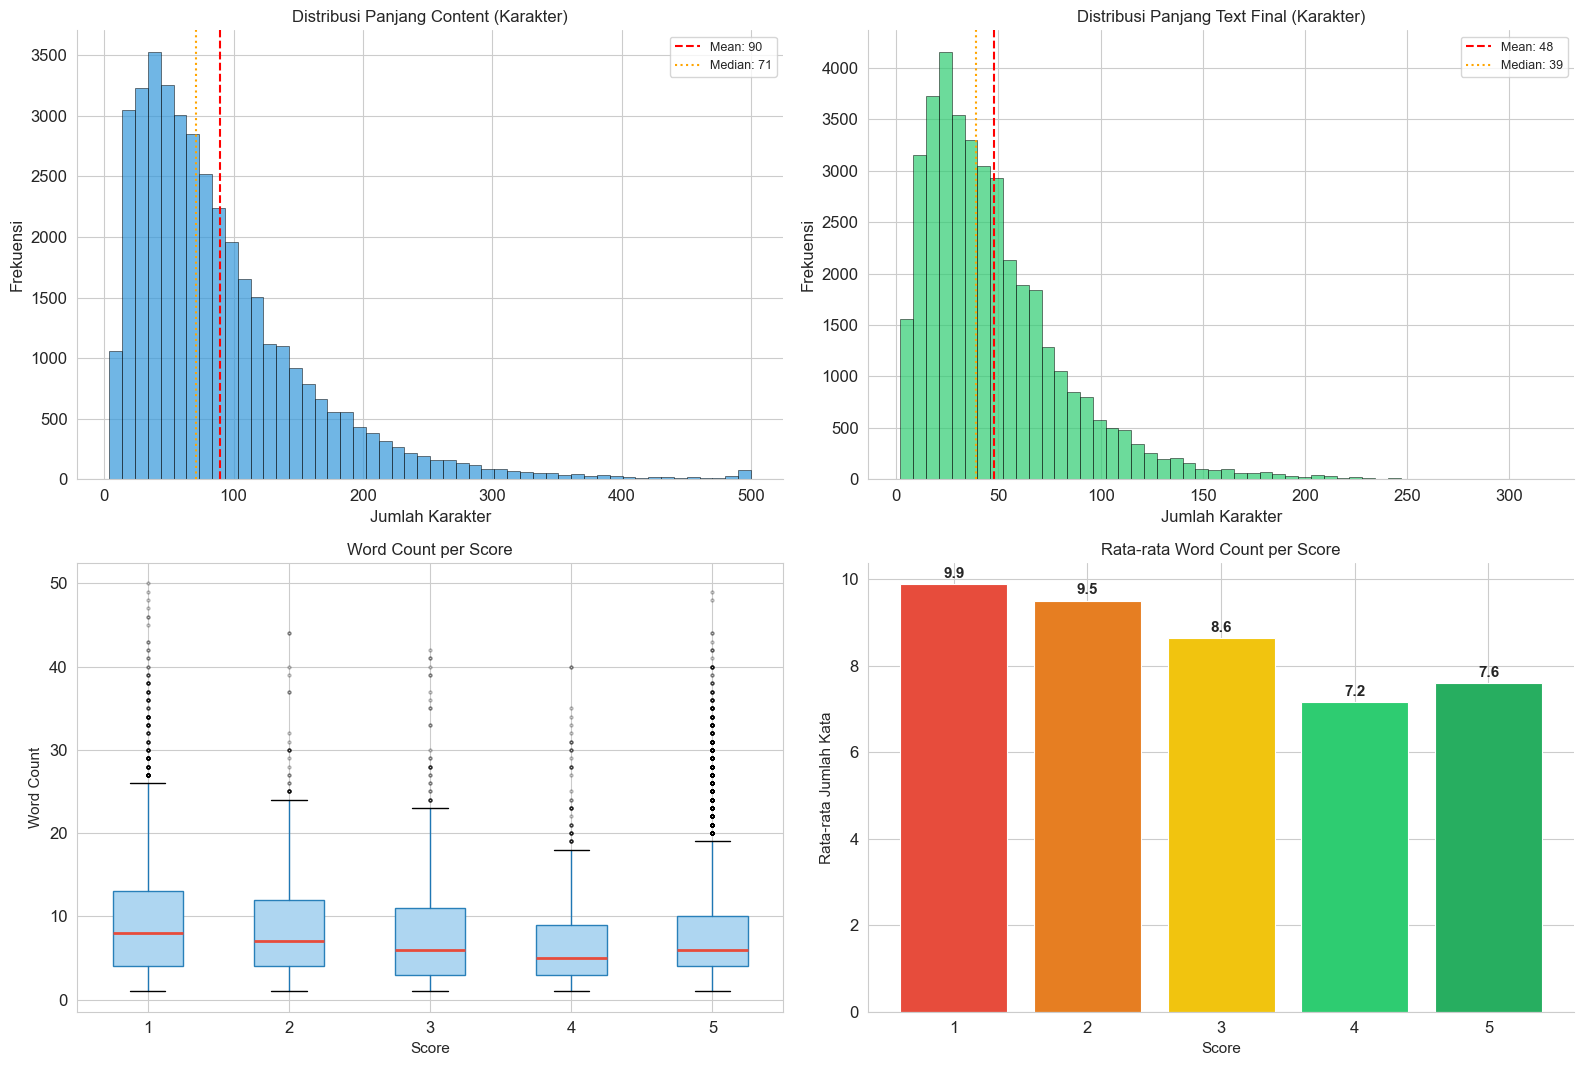

📌 Statistik Word Count:
   Mean  : 7.8 kata
   Median: 6 kata
   Max   : 50 kata

🔹 Review negatif (score 1) rata-rata 9.9 kata
🔹 Review positif (score 5) rata-rata 7.6 kata
🔹 Selisih: 2.3 kata lebih panjang untuk review negatif


In [33]:
df_clean['content_len'] = df_clean['content'].astype(str).apply(len)
df_clean['clean_len'] = df_clean['text_final'].astype(str).apply(len)
df_clean['word_count'] = df_clean['text_final'].astype(str).apply(lambda x: len(x.split()))

fig, axes = plt.subplots(2, 2, figsize=(16, 11))
fig.suptitle('📏 Analisis Panjang Review', fontsize=16, fontweight='bold', y=1.01)

# ── Histogram panjang content ──
axes[0,0].hist(df_clean['content_len'], bins=50, color='#3498db', alpha=0.7, edgecolor='black', linewidth=0.5)
axes[0,0].set_title('Distribusi Panjang Content (Karakter)', fontsize=12)
axes[0,0].set_xlabel('Jumlah Karakter')
axes[0,0].set_ylabel('Frekuensi')
axes[0,0].axvline(df_clean['content_len'].mean(), color='red', linestyle='--', linewidth=1.5,
                   label=f"Mean: {df_clean['content_len'].mean():.0f}")
axes[0,0].axvline(df_clean['content_len'].median(), color='orange', linestyle=':', linewidth=1.5,
                   label=f"Median: {df_clean['content_len'].median():.0f}")
axes[0,0].legend(fontsize=9)
axes[0,0].spines['top'].set_visible(False)
axes[0,0].spines['right'].set_visible(False)

# ── Histogram panjang text_final ──
axes[0,1].hist(df_clean['clean_len'], bins=50, color='#2ecc71', alpha=0.7, edgecolor='black', linewidth=0.5)
axes[0,1].set_title('Distribusi Panjang Text Final (Karakter)', fontsize=12)
axes[0,1].set_xlabel('Jumlah Karakter')
axes[0,1].set_ylabel('Frekuensi')
axes[0,1].axvline(df_clean['clean_len'].mean(), color='red', linestyle='--', linewidth=1.5,
                   label=f"Mean: {df_clean['clean_len'].mean():.0f}")
axes[0,1].axvline(df_clean['clean_len'].median(), color='orange', linestyle=':', linewidth=1.5,
                   label=f"Median: {df_clean['clean_len'].median():.0f}")
axes[0,1].legend(fontsize=9)
axes[0,1].spines['top'].set_visible(False)
axes[0,1].spines['right'].set_visible(False)

# ── Boxplot per score (fix suptitle hack) ──
bp = df_clean.boxplot(column='word_count', by='score', ax=axes[1,0], 
                       patch_artist=True, return_type='dict',
                       boxprops=dict(facecolor='#AED6F1', edgecolor='#2980B9'),
                       medianprops=dict(color='#E74C3C', linewidth=2),
                       flierprops=dict(marker='o', markersize=2, alpha=0.3))
axes[1,0].set_title('Word Count per Score', fontsize=12)
axes[1,0].set_xlabel('Score', fontsize=11)
axes[1,0].set_ylabel('Word Count', fontsize=11)
# Hapus auto-generated suptitle dari pandas boxplot
fig.texts = [t for t in fig.texts if 'Boxplot' not in t.get_text()]
plt.suptitle('')  # override pandas boxplot suptitle

# ── Mean word count per score ──
mean_wc = df_clean.groupby('score')['word_count'].mean()
bars = axes[1,1].bar(mean_wc.index, mean_wc.values, color=colors_bar, edgecolor='white', linewidth=0.8)
axes[1,1].set_title('Rata-rata Word Count per Score', fontsize=12)
axes[1,1].set_xlabel('Score', fontsize=11)
axes[1,1].set_ylabel('Rata-rata Jumlah Kata', fontsize=11)
axes[1,1].set_xticks(mean_wc.index)
for bar, val in zip(bars, mean_wc.values):
    axes[1,1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.15,
                   f'{val:.1f}', ha='center', fontsize=11, fontweight='bold')
axes[1,1].spines['top'].set_visible(False)
axes[1,1].spines['right'].set_visible(False)

plt.tight_layout()
plt.show()

# ── Print statistik ──
print("=" * 50)
print(f"📌 Statistik Word Count:")
print(f"   Mean  : {df_clean['word_count'].mean():.1f} kata")
print(f"   Median: {df_clean['word_count'].median():.0f} kata")
print(f"   Max   : {df_clean['word_count'].max()} kata")
print("=" * 50)
print(f"\n🔹 Review negatif (score 1) rata-rata {mean_wc[1]:.1f} kata")
print(f"🔹 Review positif (score 5) rata-rata {mean_wc[5]:.1f} kata")
print(f"🔹 Selisih: {mean_wc[1] - mean_wc[5]:.1f} kata lebih panjang untuk review negatif")

## 8) 📱 Analisis Versi Aplikasi

Menganalisis distribusi review berdasarkan versi aplikasi. Terdapat **171 versi unik** dengan **~13% review** yang tidak memiliki informasi versi.

📌 Jumlah versi unik: 171
📌 Review tanpa info versi: 4,938 (12.8%)


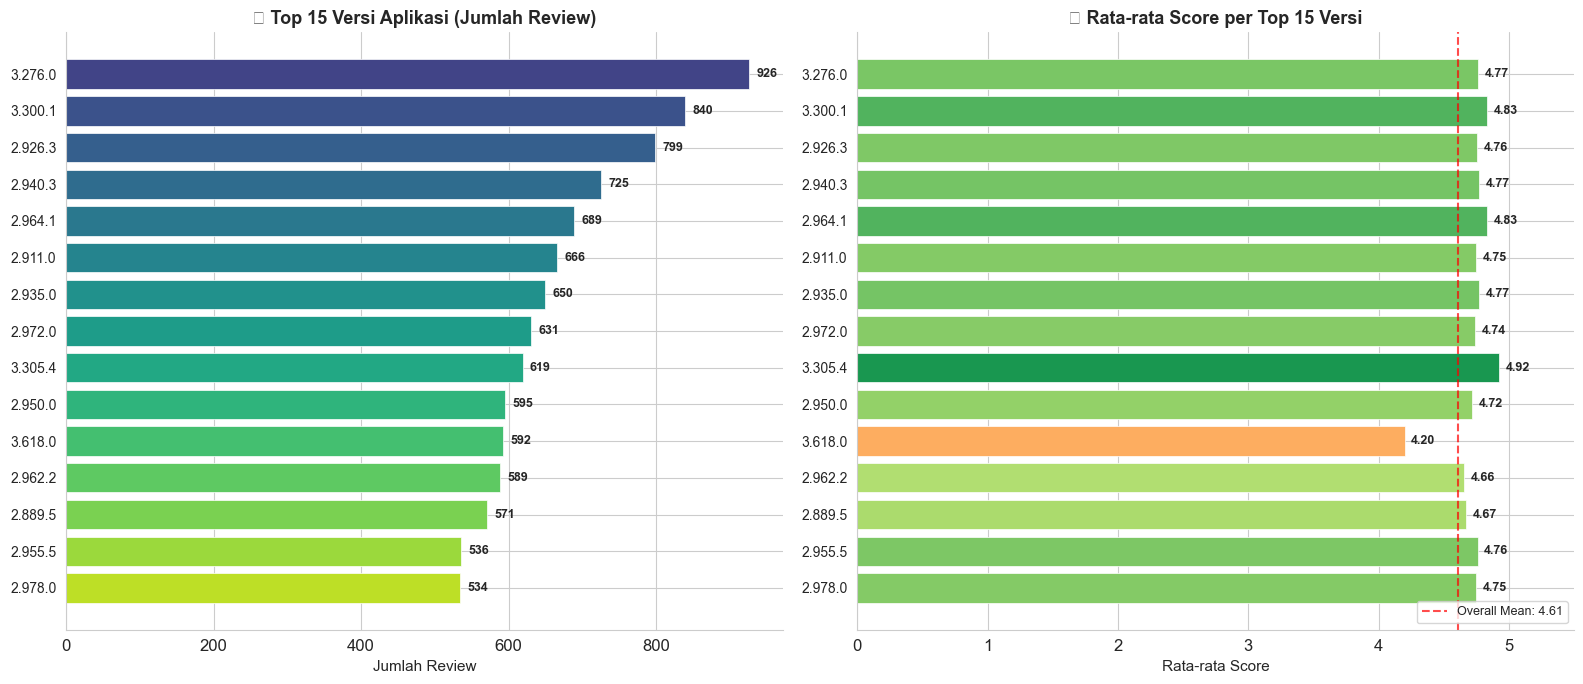


🔹 Versi paling banyak direview: 3.276.0 (926 review)
🔹 Versi dengan rata-rata score tertinggi: 3.305.4 (4.92)
🔹 Versi dengan rata-rata score terendah: 3.618.0 (4.20)


In [34]:
version_counts = df_clean['reviewCreatedVersion'].value_counts()
print(f"📌 Jumlah versi unik: {version_counts.shape[0]}")
print(f"📌 Review tanpa info versi: {df_clean['reviewCreatedVersion'].isnull().sum():,} ({df_clean['reviewCreatedVersion'].isnull().mean()*100:.1f}%)")

# Top 15 versi
top_n = 15
top_versions = version_counts.head(top_n)

fig, axes = plt.subplots(1, 2, figsize=(16, 7))

# ── Bar chart jumlah review per versi ──
colors_ver = plt.cm.viridis(np.linspace(0.2, 0.9, top_n))
bars = axes[0].barh(range(top_n), top_versions.values, color=colors_ver, edgecolor='white', linewidth=0.5)
axes[0].set_yticks(range(top_n))
axes[0].set_yticklabels(top_versions.index, fontsize=10)
axes[0].set_xlabel('Jumlah Review', fontsize=11)
axes[0].set_title(f'📊 Top {top_n} Versi Aplikasi (Jumlah Review)', fontsize=13, fontweight='bold')
axes[0].invert_yaxis()
axes[0].spines['top'].set_visible(False)
axes[0].spines['right'].set_visible(False)
for i, v in enumerate(top_versions.values):
    axes[0].text(v + 10, i, f'{v:,}', va='center', fontsize=9, fontweight='bold')

# ── Rata-rata score per top version ──
top_ver_list = top_versions.index.tolist()
avg_score_ver = df_clean[df_clean['reviewCreatedVersion'].isin(top_ver_list)] \
    .groupby('reviewCreatedVersion')['score'].mean() \
    .reindex(top_ver_list)

# Warna berdasarkan nilai score (merah=rendah, hijau=tinggi)
norm_scores = (avg_score_ver.values - avg_score_ver.values.min()) / (avg_score_ver.values.max() - avg_score_ver.values.min() + 1e-9)
score_colors = plt.cm.RdYlGn(norm_scores * 0.6 + 0.3)

bars2 = axes[1].barh(range(top_n), avg_score_ver.values, color=score_colors, edgecolor='white', linewidth=0.5)
axes[1].set_yticks(range(top_n))
axes[1].set_yticklabels(avg_score_ver.index, fontsize=10)
axes[1].set_xlabel('Rata-rata Score', fontsize=11)
axes[1].set_title(f'📊 Rata-rata Score per Top {top_n} Versi', fontsize=13, fontweight='bold')
axes[1].set_xlim(0, 5.5)
axes[1].axvline(x=df_clean['score'].mean(), color='red', linestyle='--', alpha=0.7, linewidth=1.5,
                label=f"Overall Mean: {df_clean['score'].mean():.2f}")
axes[1].invert_yaxis()
axes[1].legend(fontsize=9, loc='lower right')
axes[1].spines['top'].set_visible(False)
axes[1].spines['right'].set_visible(False)
for i, v in enumerate(avg_score_ver.values):
    axes[1].text(v + 0.05, i, f'{v:.2f}', va='center', fontsize=9, fontweight='bold')

plt.tight_layout()
plt.show()

# ── Insight versi ──
best_ver = avg_score_ver.idxmax()
worst_ver = avg_score_ver.idxmin()
print(f"\n🔹 Versi paling banyak direview: {top_versions.index[0]} ({top_versions.values[0]:,} review)")
print(f"🔹 Versi dengan rata-rata score tertinggi: {best_ver} ({avg_score_ver[best_ver]:.2f})")
print(f"🔹 Versi dengan rata-rata score terendah: {worst_ver} ({avg_score_ver[worst_ver]:.2f})")

## 9) 🔤 Analisis Efek Preprocessing

Membandingkan panjang teks asli (content) dengan teks hasil preprocessing (text_final). Preprocessing meliputi cleaning dan stemming yang mereduksi noise teks.

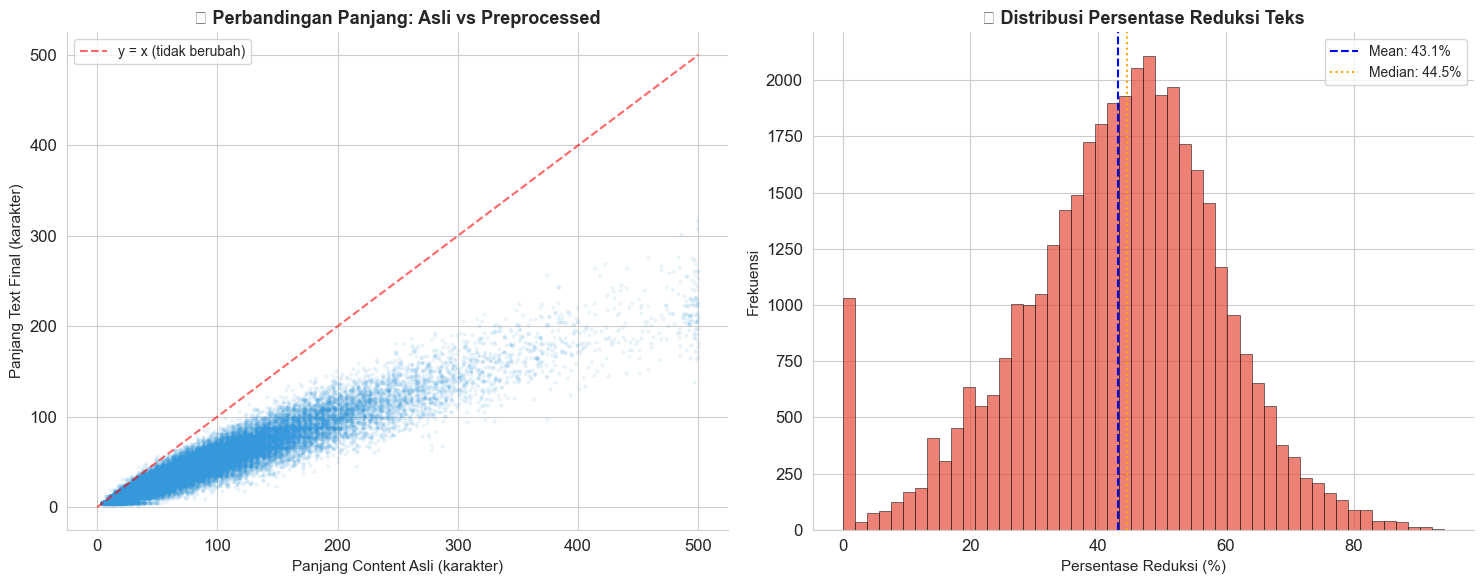

📌 Rata-rata reduksi teks : 43.1%
📌 Median reduksi teks   : 44.5%
📌 Std Dev               : 16.0%

🔹 Preprocessing mereduksi teks rata-rata ~43% dari panjang asli
🔹 Distribusi reduksi mendekati normal (bell-shaped), artinya konsisten


In [35]:
# Perbandingan panjang sebelum vs sesudah
df_clean['reduction_pct'] = ((df_clean['content_len'] - df_clean['clean_len']) / df_clean['content_len'] * 100).clip(0, 100)

fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# ── Scatter: content_len vs clean_len ──
axes[0].scatter(df_clean['content_len'], df_clean['clean_len'], alpha=0.08, s=4, color='#3498db')
axes[0].plot([0, df_clean['content_len'].max()], [0, df_clean['content_len'].max()],
             'r--', alpha=0.6, linewidth=1.5, label='y = x (tidak berubah)')
axes[0].set_xlabel('Panjang Content Asli (karakter)', fontsize=11)
axes[0].set_ylabel('Panjang Text Final (karakter)', fontsize=11)
axes[0].set_title('📊 Perbandingan Panjang: Asli vs Preprocessed', fontsize=13, fontweight='bold')
axes[0].legend(fontsize=10)
axes[0].spines['top'].set_visible(False)
axes[0].spines['right'].set_visible(False)

# ── Histogram reduksi ──
axes[1].hist(df_clean['reduction_pct'], bins=50, color='#e74c3c', alpha=0.7, edgecolor='black', linewidth=0.5)
axes[1].set_xlabel('Persentase Reduksi (%)', fontsize=11)
axes[1].set_ylabel('Frekuensi', fontsize=11)
axes[1].set_title('📊 Distribusi Persentase Reduksi Teks', fontsize=13, fontweight='bold')
axes[1].axvline(df_clean['reduction_pct'].mean(), color='blue', linestyle='--', linewidth=1.5,
                label=f"Mean: {df_clean['reduction_pct'].mean():.1f}%")
axes[1].axvline(df_clean['reduction_pct'].median(), color='orange', linestyle=':', linewidth=1.5,
                label=f"Median: {df_clean['reduction_pct'].median():.1f}%")
axes[1].legend(fontsize=10)
axes[1].spines['top'].set_visible(False)
axes[1].spines['right'].set_visible(False)

plt.tight_layout()
plt.show()

print("=" * 50)
print(f"📌 Rata-rata reduksi teks : {df_clean['reduction_pct'].mean():.1f}%")
print(f"📌 Median reduksi teks   : {df_clean['reduction_pct'].median():.1f}%")
print(f"📌 Std Dev               : {df_clean['reduction_pct'].std():.1f}%")
print("=" * 50)
print(f"\n🔹 Preprocessing mereduksi teks rata-rata ~{df_clean['reduction_pct'].mean():.0f}% dari panjang asli")
print(f"🔹 Distribusi reduksi mendekati normal (bell-shaped), artinya konsisten")

## 10) 📝 Frekuensi Kata: Positif vs Negatif

Menganalisis kata-kata yang paling sering muncul pada review **positif (score 4-5)** vs **negatif (score 1-2)** setelah menghapus stopwords bahasa Indonesia (Sastrawi).

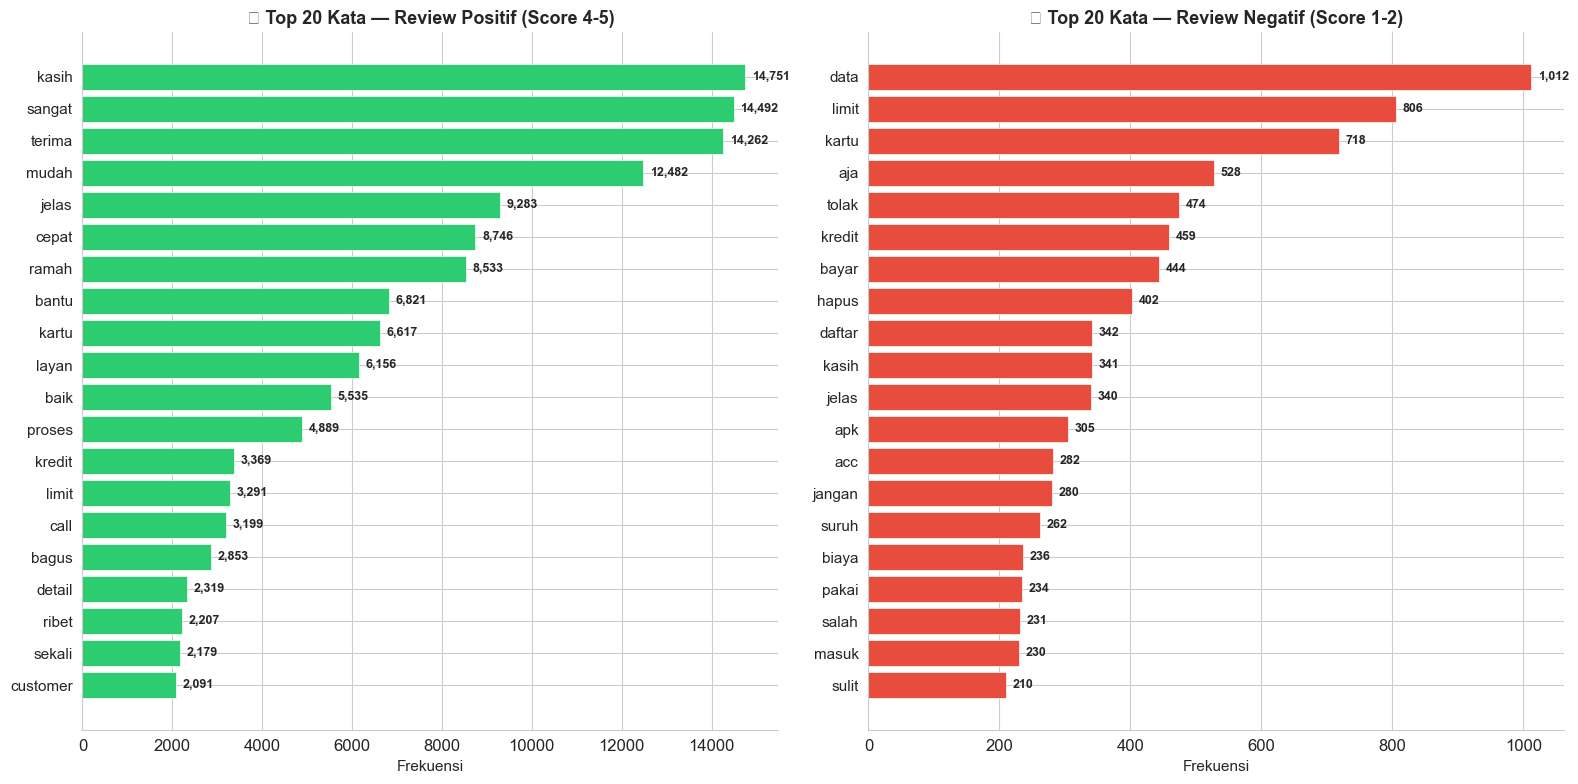

📌 Review Positif didominasi kata: kasih, sangat, terima, mudah, jelas
📌 Review Negatif didominasi kata: data, limit, kartu, aja, tolak

🔹 Kata 'kasih' & 'terima' (→ terima kasih) dominan di review positif
🔹 Kata 'data', 'limit', 'kartu' menunjukkan keluhan terkait fitur kredit & limit
🔹 Kata 'tolak' dan 'hapus' menunjukkan frustrasi pengguna


In [36]:
from Sastrawi.StopWordRemover.StopWordRemoverFactory import StopWordRemoverFactory

factory = StopWordRemoverFactory()
stopwords_id = set(factory.get_stop_words())

def get_top_words(texts, n=20):
    all_words = ' '.join(texts.astype(str)).split()
    filtered = [w for w in all_words if w not in stopwords_id and len(w) > 2]
    return Counter(filtered).most_common(n)

pos_reviews = df_clean[df_clean['score'] >= 4]['text_final']
neg_reviews = df_clean[df_clean['score'] <= 2]['text_final']

top_pos = get_top_words(pos_reviews)
top_neg = get_top_words(neg_reviews)

fig, axes = plt.subplots(1, 2, figsize=(16, 8))

# ── Positif ──
words_p, counts_p = zip(*top_pos)
bars_p = axes[0].barh(range(len(words_p)), counts_p, color='#2ecc71', edgecolor='white', linewidth=0.5)
axes[0].set_yticks(range(len(words_p)))
axes[0].set_yticklabels(words_p, fontsize=11)
axes[0].set_title('📊 Top 20 Kata — Review Positif (Score 4-5)', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Frekuensi', fontsize=11)
axes[0].invert_yaxis()
axes[0].spines['top'].set_visible(False)
axes[0].spines['right'].set_visible(False)
for i, v in enumerate(counts_p):
    axes[0].text(v + max(counts_p)*0.01, i, f'{v:,}', va='center', fontsize=9, fontweight='bold')

# ── Negatif ──
words_n, counts_n = zip(*top_neg)
bars_n = axes[1].barh(range(len(words_n)), counts_n, color='#e74c3c', edgecolor='white', linewidth=0.5)
axes[1].set_yticks(range(len(words_n)))
axes[1].set_yticklabels(words_n, fontsize=11)
axes[1].set_title('📊 Top 20 Kata — Review Negatif (Score 1-2)', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Frekuensi', fontsize=11)
axes[1].invert_yaxis()
axes[1].spines['top'].set_visible(False)
axes[1].spines['right'].set_visible(False)
for i, v in enumerate(counts_n):
    axes[1].text(v + max(counts_n)*0.01, i, f'{v:,}', va='center', fontsize=9, fontweight='bold')

plt.tight_layout()
plt.show()

# ── Insight kata ──
print("=" * 50)
print(f"📌 Review Positif didominasi kata: {', '.join(words_p[:5])}")
print(f"📌 Review Negatif didominasi kata: {', '.join(words_n[:5])}")
print("=" * 50)
print(f"\n🔹 Kata 'kasih' & 'terima' (→ terima kasih) dominan di review positif")
print(f"🔹 Kata 'data', 'limit', 'kartu' menunjukkan keluhan terkait fitur kredit & limit")
print(f"🔹 Kata 'tolak' dan 'hapus' menunjukkan frustrasi pengguna")

## 11) 📈 Analisis Korelasi

Menghitung korelasi antara variabel numerik yang tersedia.

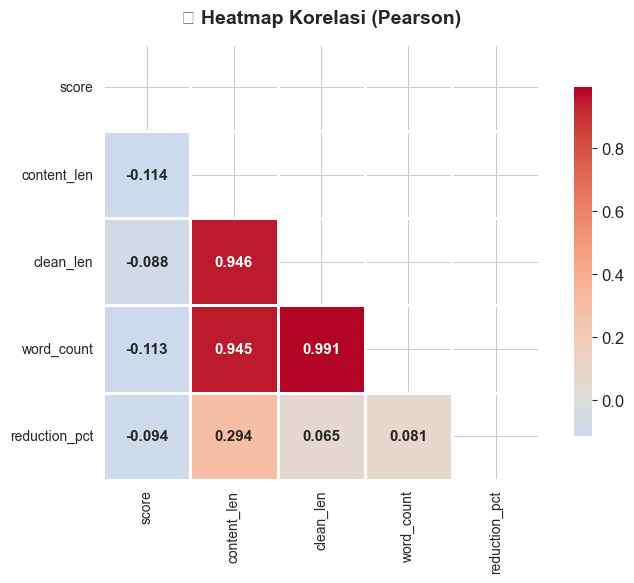

📌 Insight Korelasi:
  🔹 content_len ↔ clean_len: 0.946 (KUAT positif)
  🔹 content_len ↔ word_count: 0.945 (KUAT positif)
  🔹 clean_len ↔ word_count: 0.991 (KUAT positif)

🔹 clean_len dan word_count hampir identik (r=0.991) — redundan
🔹 Score tidak berkorelasi kuat dengan panjang review (r≈-0.11)


In [37]:
corr_cols = ['score', 'content_len', 'clean_len', 'word_count', 'reduction_pct']
corr_matrix = df_clean[corr_cols].corr()

plt.figure(figsize=(8, 6))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(corr_matrix, mask=mask, annot=True, fmt='.3f', cmap='coolwarm',
            center=0, square=True, linewidths=1, linecolor='white',
            annot_kws={'fontsize': 11, 'fontweight': 'bold'},
            cbar_kws={'shrink': 0.8})
plt.title('📊 Heatmap Korelasi (Pearson)', fontsize=14, fontweight='bold', pad=15)
plt.xticks(fontsize=10)
plt.yticks(fontsize=10)
plt.tight_layout()
plt.show()

# ── Insight korelasi ──
print("=" * 50)
print("📌 Insight Korelasi:")
for i in range(len(corr_cols)):
    for j in range(i+1, len(corr_cols)):
        val = corr_matrix.iloc[i, j]
        if abs(val) >= 0.3:
            strength = "KUAT" if abs(val) >= 0.6 else "sedang"
            direction = "positif" if val > 0 else "negatif"
            print(f"  🔹 {corr_cols[i]} ↔ {corr_cols[j]}: {val:.3f} ({strength} {direction})")
print("=" * 50)
print(f"\n🔹 clean_len dan word_count hampir identik (r=0.991) — redundan")
print(f"🔹 Score tidak berkorelasi kuat dengan panjang review (r≈-0.11)")

## 12) 📘 Regex Quickstart — Fungsi Utama Python `re`

Demo 5 fungsi inti modul `re` pada sample review:
| Fungsi | Kegunaan |
|--------|----------|
| `re.search()` | Cari pola pertama di mana saja dalam string |
| `re.match()` | Match hanya di **awal** string |
| `re.findall()` | Kembalikan **semua** match sebagai list |
| `re.sub()` | Find & replace dengan regex |
| `re.compile()` | Compile pattern sekali, gunakan berulang kali |

Referensi: [Python re docs](https://docs.python.org/3/library/re.html) · [RexEgg Cheat Sheet](https://www.rexegg.com/regex-quickstart.php)

In [38]:
# ── Quick Demo: re.search, re.match, re.findall, re.sub, re.compile ──
sample_reviews = [
    "Aplikasi bagus!! Versi 2.3.1 sangat stabil 🎉",
    "BUG di versi 1.0.0, tolong fix ASAP @developer",
    "Rating 5/5. Download di https://play.google.com/honest",
    "Fitur baru keren, tapi loading lama banget 😤😤😤",
]

print("=" * 70)
print("📘 REGEX QUICKSTART — Fungsi Utama Python `re`")
print("=" * 70)

# 1. re.search — cari pertama match di mana saja
print("\n🔍 re.search (cari pola pertama di string):")
for r in sample_reviews:
    m = re.search(r'\d+\.\d+\.\d+', r)
    print(f'   "{r[:50]}" → Versi: {m.group() if m else "—"}')

# 2. re.match — match di AWAL string saja
print("\n📍 re.match (match dari awal string):")
for r in sample_reviews:
    m = re.match(r'[A-Z]', r)
    print(f'   "{r[:40]}" → Huruf kapital awal: {m.group() if m else "—"}')

# 3. re.findall — semua match sebagai list
print("\n📋 re.findall (semua match):")
for r in sample_reviews:
    emojis = re.findall(r'[\U0001F600-\U0001F64F\U0001F680-\U0001F6FF\U0001F900-\U0001F9FF]', r)
    print(f'   "{r[:40]}" → Emoji: {emojis if emojis else "—"}')

# 4. re.sub — find & replace
print("\n🔄 re.sub (ganti pola):")
for r in sample_reviews:
    cleaned = re.sub(r'https?://\S+', '[URL]', r)
    cleaned = re.sub(r'@\w+', '[MENTION]', cleaned)
    if cleaned != r:
        print(f'   BEFORE: "{r[:60]}"')
        print(f'   AFTER : "{cleaned[:60]}"')

# 5. re.compile — compile pattern sekali, pakai berkali-kali
print("\n⚡ re.compile (pre-compiled pattern):")
pat_version = re.compile(r'(\d+)\.(\d+)\.(\d+)')
for r in sample_reviews:
    m = pat_version.search(r)
    if m:
        major, minor, patch = m.groups()
        print(f'   "{r[:50]}" → Major={major}, Minor={minor}, Patch={patch}')

📘 REGEX QUICKSTART — Fungsi Utama Python `re`

🔍 re.search (cari pola pertama di string):
   "Aplikasi bagus!! Versi 2.3.1 sangat stabil 🎉" → Versi: 2.3.1
   "BUG di versi 1.0.0, tolong fix ASAP @developer" → Versi: 1.0.0
   "Rating 5/5. Download di https://play.google.com/ho" → Versi: —
   "Fitur baru keren, tapi loading lama banget 😤😤😤" → Versi: —

📍 re.match (match dari awal string):
   "Aplikasi bagus!! Versi 2.3.1 sangat stab" → Huruf kapital awal: A
   "BUG di versi 1.0.0, tolong fix ASAP @dev" → Huruf kapital awal: B
   "Rating 5/5. Download di https://play.goo" → Huruf kapital awal: R
   "Fitur baru keren, tapi loading lama bang" → Huruf kapital awal: F

📋 re.findall (semua match):
   "Aplikasi bagus!! Versi 2.3.1 sangat stab" → Emoji: —
   "BUG di versi 1.0.0, tolong fix ASAP @dev" → Emoji: —
   "Rating 5/5. Download di https://play.goo" → Emoji: —
   "Fitur baru keren, tapi loading lama bang" → Emoji: ['😤', '😤', '😤']

🔄 re.sub (ganti pola):
   BEFORE: "BUG di versi 1.0.0, tol

## 13) 🧹 Pembersihan Teks Review dengan `re.sub()`

Multi-step regex cleaning: hapus URL → mention → hashtag → angka → non-alfabet → normalkan spasi. Membuat kolom baru `content_regex_clean` yang akan digunakan di section-section berikutnya.

In [39]:
# ── Fungsi regex cleaning multi-step ──
def regex_clean(text):
    """Pembersihan teks review menggunakan re.sub() multi-step"""
    if pd.isna(text):
        return ''
    text = str(text).lower()
    text = re.sub(r'https?://\S+', '', text)           # hapus URL
    text = re.sub(r'@\w+', '', text)                    # hapus mention
    text = re.sub(r'#\w+', '', text)                    # hapus hashtag
    text = re.sub(r'\d+', '', text)                     # hapus angka
    text = re.sub(r'[^a-zA-Z\s]', '', text)             # hapus non-alfabet
    text = re.sub(r'\s+', ' ', text).strip()            # normalkan spasi
    return text

# ── Terapkan ke dataset ──
df_clean['content_regex_clean'] = df_clean['content'].apply(regex_clean)

# ── Statistik sebelum vs sesudah ──
before_len = df_clean['content'].astype(str).str.len()
after_len  = df_clean['content_regex_clean'].str.len()
reduction  = ((before_len - after_len) / before_len * 100).mean()

print(f"📊 Rata-rata panjang SEBELUM : {before_len.mean():.0f} karakter")
print(f"📊 Rata-rata panjang SESUDAH : {after_len.mean():.0f} karakter")
print(f"📊 Rata-rata reduksi         : {reduction:.1f}%")

# ── Contoh sebelum/sesudah ──
print("\n📌 Contoh Sebelum → Sesudah:")
sample_idx = df_clean[df_clean['content'].str.len() > 30].head(5).index
for i in sample_idx:
    print(f"\n  BEFORE: \"{str(df_clean.loc[i, 'content'])[:80]}\"")
    print(f"  AFTER : \"{df_clean.loc[i, 'content_regex_clean'][:80]}\"")

📊 Rata-rata panjang SEBELUM : 90 karakter
📊 Rata-rata panjang SESUDAH : 87 karakter
📊 Rata-rata reduksi         : 3.1%

📌 Contoh Sebelum → Sesudah:

  BEFORE: "ini adalah pertama kali saya menggunakan kartu kredit. yang katanya cocok buat a"
  AFTER : "ini adalah pertama kali saya menggunakan kartu kredit yang katanya cocok buat an"

  BEFORE: "pengajuan berhasil, pelayanan utk CS atas nama Rio sangat sopan dan penjelasan s"
  AFTER : "pengajuan berhasil pelayanan utk cs atas nama rio sangat sopan dan penjelasan sa"

  BEFORE: "penjelasan yang baik oleh mba rima"
  AFTER : "penjelasan yang baik oleh mba rima"

  BEFORE: "trimakasih mba ulfa atas panduan nya sangat demengerti...dan trimakasih kepada a"
  AFTER : "trimakasih mba ulfa atas panduan nya sangat demengertidan trimakasih kepada apli"

  BEFORE: "ok mantep gampang aktifnya dan costemernya mas Fariz ramah dan enak di ajak ngob"
  AFTER : "ok mantep gampang aktifnya dan costemernya mas fariz ramah dan enak di ajak ngob"


## 14) 🚨 Deteksi Keluhan dengan Regex

Menggunakan 6 **compiled regex patterns** untuk mengklasifikasikan keluhan pengguna: Bug/Error, Lambat, UI/UX, Login, Iklan, dan Fitur Hilang. Dilengkapi analisis rata-rata score per kategori dan cross-pattern analysis.

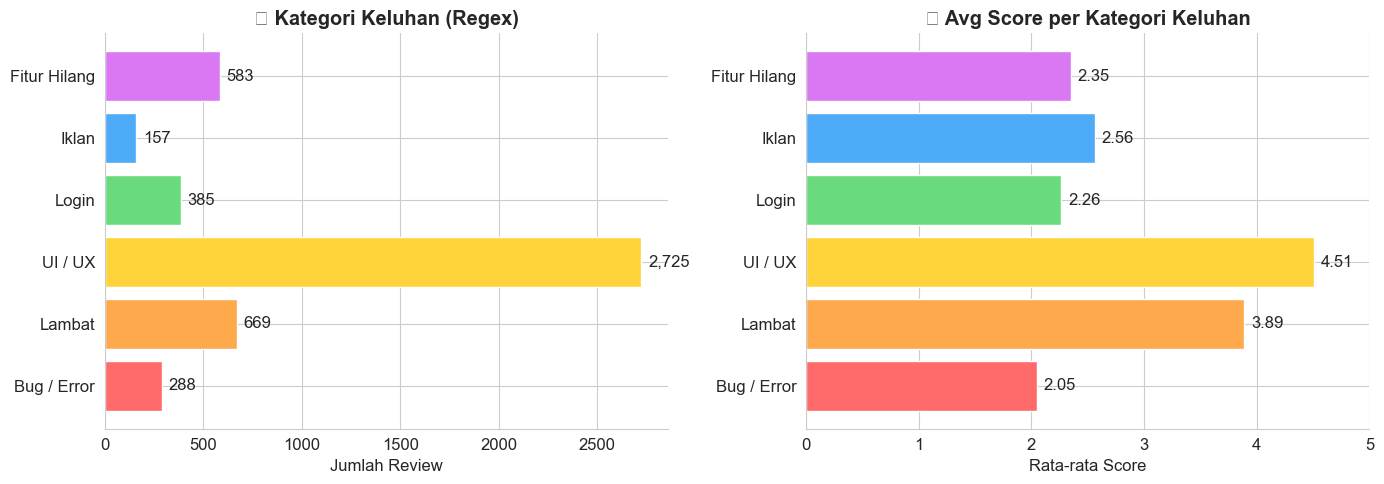


🔍 Cross-pattern: review yang cocok >1 kategori:
   377 dari 38,709 review (1.0%) cocok ≥2 kategori


In [40]:
# ── Compiled complaint patterns ──
complaint_patterns = {
    'Bug / Error':  re.compile(r'\b(bug|error|crash|force\s*close|not\s*working|gagal|rusak)\b', re.I),
    'Lambat':       re.compile(r'\b(lama|lambat|slow|lag|lemot|loading)\b', re.I),
    'UI / UX':      re.compile(r'\b(ribet|bingung|susah|sulit|tidak\s*jelas|confusing|complicated)\b', re.I),
    'Login':        re.compile(r'\b(login|log\s*in|sign\s*in|masuk|otp|verifikas)\b', re.I),
    'Iklan':        re.compile(r'\b(iklan|ads|adverti|promo\s*terus)\b', re.I),
    'Fitur Hilang': re.compile(r'\b(hilang|hapus|ilang|remove|missing|kurang)\b', re.I),
}

# ── Deteksi di seluruh review ──
complaint_counts = {k: 0 for k in complaint_patterns}
complaint_scores = {k: [] for k in complaint_patterns}

for _, row in df_clean[['content', 'score']].dropna(subset=['content']).iterrows():
    text = str(row['content'])
    for cat, pat in complaint_patterns.items():
        if pat.search(text):
            complaint_counts[cat] += 1
            complaint_scores[cat].append(row['score'])

# ── Visualisasi ──
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Bar chart jumlah
cats = list(complaint_counts.keys())
counts = list(complaint_counts.values())
colors_cmp = ['#FF6B6B', '#FFA94D', '#FFD43B', '#69DB7C', '#4DABF7', '#DA77F2']
bars = axes[0].barh(cats, counts, color=colors_cmp)
axes[0].bar_label(bars, fmt='{:,.0f}', padding=5)
axes[0].set_xlabel('Jumlah Review')
axes[0].set_title('📊 Kategori Keluhan (Regex)', fontweight='bold')
axes[0].spines[['top', 'right']].set_visible(False)

# Avg score per category
avg_scores = {k: (sum(v)/len(v) if v else 0) for k, v in complaint_scores.items()}
bars2 = axes[1].barh(cats, list(avg_scores.values()), color=colors_cmp)
axes[1].bar_label(bars2, fmt='{:.2f}', padding=5)
axes[1].set_xlabel('Rata-rata Score')
axes[1].set_title('⭐ Avg Score per Kategori Keluhan', fontweight='bold')
axes[1].set_xlim(0, 5)
axes[1].spines[['top', 'right']].set_visible(False)

plt.tight_layout()
plt.show()

# ── Cross-pattern analysis ──
print("\n🔍 Cross-pattern: review yang cocok >1 kategori:")
multi_match = 0
for text in df_clean['content'].dropna().astype(str):
    matched = sum(1 for pat in complaint_patterns.values() if pat.search(text))
    if matched > 1:
        multi_match += 1
total_reviewed = df_clean['content'].dropna().shape[0]
print(f"   {multi_match:,} dari {total_reviewed:,} review ({multi_match/total_reviewed*100:.1f}%) cocok ≥2 kategori")

## 15) 🔖 Named Groups: Ekstraksi Entitas

Menggunakan **named capturing groups** `(?P<name>...)` untuk mengekstrak entitas terstruktur: tanggal, uang (Rp), telepon, waktu, dan angka. Termasuk demo `.groupdict()` untuk akses per-group.

📊 Entity Detection via Named Groups:
   Tanggal   :     56 ditemukan
   Uang      :    284 ditemukan
   Telepon   :      0 ditemukan
   Waktu     :     13 ditemukan
   Angka     :    720 ditemukan


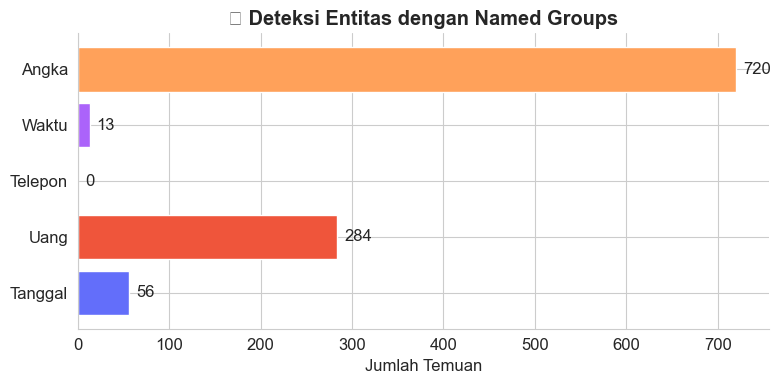


📌 Demo .groupdict():
   Tanggal: 25/12/2024 → {'day': '25', 'month': '12', 'year': '2024'}
   Uang: Rp 50.000 → {'amount': '50.000'}
   Waktu: 14:30 → {'hour': '14', 'minute': '30', 'second': None}
   Angka: 000 → {'number': '000'}


In [41]:
# ── Named group patterns ──
named_patterns = {
    'Tanggal': re.compile(r'(?P<day>\d{1,2})[/-](?P<month>\d{1,2})[/-](?P<year>\d{2,4})'),
    'Uang':    re.compile(r'(?:Rp\.?\s?)(?P<amount>[\d.,]+)'),
    'Telepon': re.compile(r'(?P<phone>(?:0|\+62)\d{9,12})'),
    'Waktu':   re.compile(r'(?P<hour>\d{1,2}):(?P<minute>\d{2})(?::(?P<second>\d{2}))?'),
    'Angka':   re.compile(r'\b(?P<number>\d{3,})\b'),
}

# ── Scan seluruh review ──
entity_counts = {k: 0 for k in named_patterns}
entity_examples = {k: [] for k in named_patterns}

for text in df_clean['content'].dropna().astype(str):
    for name, pat in named_patterns.items():
        matches = list(pat.finditer(text))
        entity_counts[name] += len(matches)
        for m in matches[:2]:
            if len(entity_examples[name]) < 5:
                entity_examples[name].append(m.group())

# ── Tampilkan statistik ──
print("📊 Entity Detection via Named Groups:")
for name, count in entity_counts.items():
    print(f"   {name:10s}: {count:>6,} ditemukan")

# ── Visualisasi ──
fig, ax = plt.subplots(figsize=(8, 4))
names = list(entity_counts.keys())
counts = list(entity_counts.values())
colors_entity = ['#636EFA', '#EF553B', '#00CC96', '#AB63FA', '#FFA15A']
bars = ax.barh(names, counts, color=colors_entity)
ax.bar_label(bars, fmt='{:,.0f}', padding=5)
ax.set_xlabel('Jumlah Temuan')
ax.set_title('🔖 Deteksi Entitas dengan Named Groups', fontweight='bold')
ax.spines[['top', 'right']].set_visible(False)
plt.tight_layout()
plt.show()

# ── Demo .groupdict() ──
print("\n📌 Demo .groupdict():")
demo_text = "Transfer Rp 50.000 pada 25/12/2024 jam 14:30"
for name, pat in named_patterns.items():
    m = pat.search(demo_text)
    if m:
        print(f"   {name}: {m.group()} → {m.groupdict()}")

## 16) 📧 Validasi & Ekstraksi Email / URL

Menggunakan **compiled regex** untuk mendeteksi email, URL, dan domain di seluruh review. Termasuk validasi format email dengan `re.fullmatch()`.

In [42]:
# ── Compiled patterns ──
pat_email  = re.compile(r'[a-zA-Z0-9._%+-]+@[a-zA-Z0-9.-]+\.[a-zA-Z]{2,}')
pat_url    = re.compile(r'https?://[^\s<>"\']+')
pat_domain = re.compile(r'\b(?:www\.)?[a-zA-Z0-9-]+\.[a-zA-Z]{2,}\b')

# ── Deteksi di seluruh review ──
email_found, url_found, domain_found = [], [], []
for text in df_clean['content'].dropna().astype(str):
    email_found  += pat_email.findall(text)
    url_found    += pat_url.findall(text)
    domain_found += pat_domain.findall(text)

print(f"📧 Email ditemukan : {len(email_found):,}   (unique: {len(set(email_found))})")
print(f"🔗 URL ditemukan   : {len(url_found):,}   (unique: {len(set(url_found))})")
print(f"🌐 Domain ditemukan: {len(domain_found):,}   (unique: {len(set(domain_found))})")

# ── Top hasil ──
for label, items in [('Email', email_found), ('URL', url_found), ('Domain', domain_found)]:
    top = pd.Series(items).value_counts().head(5)
    if len(top):
        print(f"\n  Top 5 {label}:")
        for v, c in top.items():
            print(f"    {v} → {c}x")

# ── Validasi format email ──
print("\n✅ Validasi Format Email (test cases):")
test_emails = ['user@gmail.com', 'bad@', 'hello@domain.co.id', '@missing.com', 'test@domain']
for t in test_emails:
    valid = bool(re.fullmatch(r'[a-zA-Z0-9._%+-]+@[a-zA-Z0-9.-]+\.[a-zA-Z]{2,}', t))
    print(f"   {t:30s} → {'✅ VALID' if valid else '❌ INVALID'}")

📧 Email ditemukan : 0   (unique: 0)
🔗 URL ditemukan   : 0   (unique: 0)
🌐 Domain ditemukan: 1,630   (unique: 1461)

  Top 5 Domain:
    cs.nya → 12x
    ramah.terima → 9x
    nya.dan → 8x
    saya.dan → 8x
    cepat.pelayanan → 6x

✅ Validasi Format Email (test cases):
   user@gmail.com                 → ✅ VALID
   bad@                           → ❌ INVALID
   hello@domain.co.id             → ✅ VALID
   @missing.com                   → ❌ INVALID
   test@domain                    → ❌ INVALID


## 17) 🕌 Studi Kasus: Cleaning Review SIAR Halal

Menerapkan regex cleaning pada dataset terpisah **SIAR Halal** (`siarhalal-main/out.csv`) untuk membandingkan dua metode:
1. **Simple** — lowercase + hapus punctuation (gaya notebook `siarhalal-main`)
2. **Advanced** — multi-step regex (URL, mention, hashtag, angka, non-alfabet)

📌 SIAR Halal: 72 baris × 12 kolom
   Kolom: ['no', 'money_spent', 'username', 'umkm', 'review', 'batas_bawah', 'batas_atas', 'median', 'rating', 'cleaned_review', 'sentiment_polarity', 'sentiment_subjective']

📌 Kolom review: 'review'


,Metode,Avg Panjang,Reduksi (%)
0,Original,35.513889,0.000000
1,Simple (siarhalal),35.250000,0.743058
2,Advanced (multi-step),34.736111,2.190066


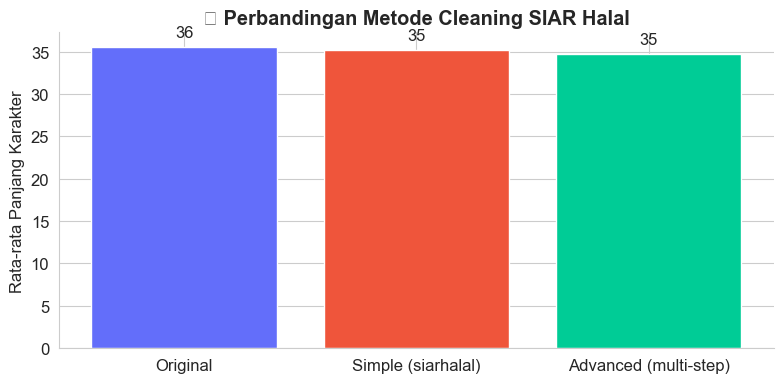


📌 Contoh Cleaning SIAR Halal:

  [1] ORIGINAL : "tidak ada transcript"
       SIMPLE   : "tidak ada transcript"
       ADVANCED : "tidak ada transcript"

  [2] ORIGINAL : "baksonya enak"
       SIMPLE   : "baksonya enak"
       ADVANCED : "baksonya enak"

  [3] ORIGINAL : "baksonya enak abis"
       SIMPLE   : "baksonya enak abis"
       ADVANCED : "baksonya enak abis"


In [43]:
# ── Load dataset SIAR Halal ──
siar_path = '../Week 3/siarhalal-main/out.csv'
df_siar = pd.read_csv(siar_path)
print(f"📌 SIAR Halal: {df_siar.shape[0]} baris × {df_siar.shape[1]} kolom")
print(f"   Kolom: {list(df_siar.columns)}")

# ── Regex cleaning sederhana (gaya siarhalal-main) ──
def siar_clean_simple(text):
    """Metode dari notebook siarhalal: lowercase + hapus punctuation"""
    if pd.isna(text):
        return ''
    text = str(text).lower()
    text = re.sub(r'[^\w\s]', '', text)
    return text.strip()

# ── Regex cleaning advanced (multi-step seperti Section 13) ──
def siar_clean_advanced(text):
    """Metode multi-step yang kita kembangkan"""
    if pd.isna(text):
        return ''
    text = str(text).lower()
    text = re.sub(r'https?://\S+', '', text)
    text = re.sub(r'@\w+', '', text)
    text = re.sub(r'#\w+', '', text)
    text = re.sub(r'\d+', '', text)
    text = re.sub(r'[^a-zA-Z\s]', '', text)
    text = re.sub(r'\s+', ' ', text).strip()
    return text

# ── Identifikasi kolom review ──
review_col = 'review' if 'review' in df_siar.columns else ('user_review' if 'user_review' in df_siar.columns else df_siar.columns[0])
print(f"\n📌 Kolom review: '{review_col}'")

df_siar['clean_simple']   = df_siar[review_col].apply(siar_clean_simple)
df_siar['clean_advanced'] = df_siar[review_col].apply(siar_clean_advanced)

# ── Perbandingan ──
len_orig = df_siar[review_col].astype(str).str.len().mean()
len_simple = df_siar['clean_simple'].str.len().mean()
len_advanced = df_siar['clean_advanced'].str.len().mean()

compare_data = {
    'Metode': ['Original', 'Simple (siarhalal)', 'Advanced (multi-step)'],
    'Avg Panjang': [len_orig, len_simple, len_advanced],
    'Reduksi (%)': [0, (1-len_simple/len_orig)*100, (1-len_advanced/len_orig)*100],
}
df_compare = pd.DataFrame(compare_data)
display(df_compare)

# ── Visualisasi perbandingan ──
fig, ax = plt.subplots(figsize=(8, 4))
colors_siar = ['#636EFA', '#EF553B', '#00CC96']
bars = ax.bar(df_compare['Metode'], df_compare['Avg Panjang'], color=colors_siar)
ax.bar_label(bars, fmt='{:.0f}', padding=5)
ax.set_ylabel('Rata-rata Panjang Karakter')
ax.set_title('🕌 Perbandingan Metode Cleaning SIAR Halal', fontweight='bold')
ax.spines[['top', 'right']].set_visible(False)
plt.tight_layout()
plt.show()

# ── Contoh before/after ──
print("\n📌 Contoh Cleaning SIAR Halal:")
for i in range(min(3, len(df_siar))):
    print(f"\n  [{i+1}] ORIGINAL : \"{str(df_siar[review_col].iloc[i])[:80]}\"")
    print(f"       SIMPLE   : \"{df_siar['clean_simple'].iloc[i][:80]}\"")
    print(f"       ADVANCED : \"{df_siar['clean_advanced'].iloc[i][:80]}\"")

## 18) 🔧 Normalisasi Teks Lanjutan

Menangani artefak teks yang belum ditangani cleaning dasar:
1. **Emoji removal**: `[\U00010000-\U0010ffff]` dan pola emoji umum
2. **Repeated chars**: `(\w)\1{2,}` → `\1` (contoh: "baguuuus" → "bagus")
3. **Excess punctuation**: `([!?.]){2,}` → `\1`
4. **Stopwords removal** via Sastrawi `get_stop_words()`

📌 Jumlah stopwords Sastrawi: 123
   Contoh: ['juga', 'ia', 'apakah', 'mari', 'pula', 'anda', 'tentang', 'begitu', 'sampai', 'belum']

📌 Demo Repeated Character Fix:
   baguuuus             → bagus
   kereeeen             → keren
   jeleeeeek            → jelek
   mantaaaap            → mantap
   hellooo              → hello

📌 Panjang rata-rata SEBELUM normalisasi: 87 karakter
📌 Panjang rata-rata SETELAH normalisasi: 74 karakter
📌 Reduksi tambahan: 14.6%


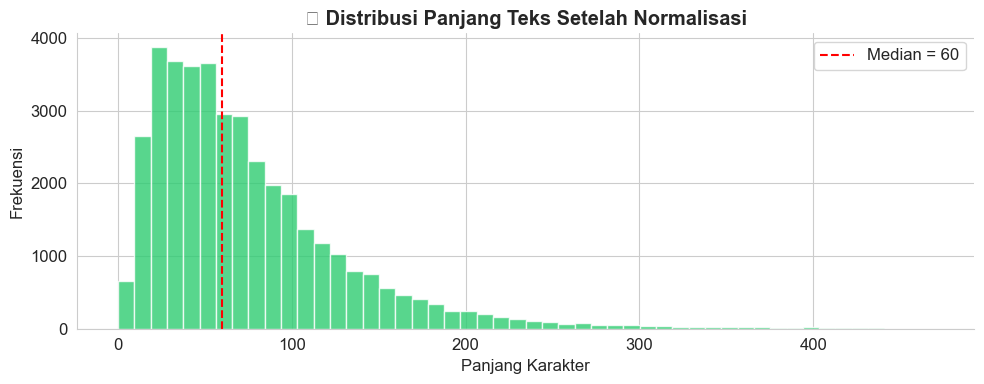

In [44]:
from Sastrawi.StopWordRemover.StopWordRemoverFactory import StopWordRemoverFactory

# ── Sastrawi stopwords ──
factory_sw = StopWordRemoverFactory()
stop_words = set(factory_sw.get_stop_words())
print(f"📌 Jumlah stopwords Sastrawi: {len(stop_words)}")
print(f"   Contoh: {list(stop_words)[:10]}")

def normalize_text(text):
    """Normalisasi lanjutan: emoji, repeated chars, stopwords"""
    if pd.isna(text) or text == '':
        return ''
    # Hapus emoji (supplementary Unicode planes)
    text = re.sub(r'[\U00010000-\U0010ffff]', '', text)
    # Hapus repeated characters (3+ → 1): baguuuus → bagus
    text = re.sub(r'(\w)\1{2,}', r'\1', text)
    # Hapus excess punctuation
    text = re.sub(r'([!?.]){2,}', r'\1', text)
    # Remove stopwords
    tokens = text.split()
    tokens = [t for t in tokens if t.lower() not in stop_words]
    return ' '.join(tokens)

# ── Terapkan ──
df_clean['content_normalized'] = df_clean['content_regex_clean'].apply(normalize_text)

# ── Demo repeated chars ──
demo_words = ["baguuuus", "kereeeen", "jeleeeeek", "mantaaaap", "hellooo"]
print("\n📌 Demo Repeated Character Fix:")
for w in demo_words:
    fixed = re.sub(r'(\w)\1{2,}', r'\1', w)
    print(f"   {w:20s} → {fixed}")

# ── Statistik ──
avg_before_norm = df_clean['content_regex_clean'].str.len().mean()
avg_after_norm = df_clean['content_normalized'].str.len().mean()
print(f"\n📌 Panjang rata-rata SEBELUM normalisasi: {avg_before_norm:.0f} karakter")
print(f"📌 Panjang rata-rata SETELAH normalisasi: {avg_after_norm:.0f} karakter")
print(f"📌 Reduksi tambahan: {(1 - avg_after_norm/avg_before_norm)*100:.1f}%")

# ── Distribusi panjang teks setelah normalisasi ──
fig, ax = plt.subplots(figsize=(10, 4))
ax.hist(df_clean['content_normalized'].str.len(), bins=50, color='#2ecc71', edgecolor='white', alpha=0.8)
ax.axvline(df_clean['content_normalized'].str.len().median(), color='red', linestyle='--',
           label=f"Median = {df_clean['content_normalized'].str.len().median():.0f}")
ax.set_xlabel('Panjang Karakter')
ax.set_ylabel('Frekuensi')
ax.set_title('🔧 Distribusi Panjang Teks Setelah Normalisasi', fontweight='bold')
ax.legend()
ax.spines[['top', 'right']].set_visible(False)
plt.tight_layout()
plt.show()

## 19) 📊 Perbandingan Pipeline: Original → Regex Clean → Normalized

Membandingkan statistik teks di setiap tahap preprocessing menggunakan grouped bar chart dan tabel ringkasan.

📊 Pipeline Processing Statistics


,Stage,Avg Length,Median Length,Avg Tokens,Empty Count,Unique Tokens
0,Original (content),89.7,71.0,13.8,0,40430
1,text_final (existing),47.7,39.0,7.8,0,3091
2,Regex Clean,86.7,69.0,13.5,0,22047
3,Normalized,74.0,60.0,11.0,2,21534


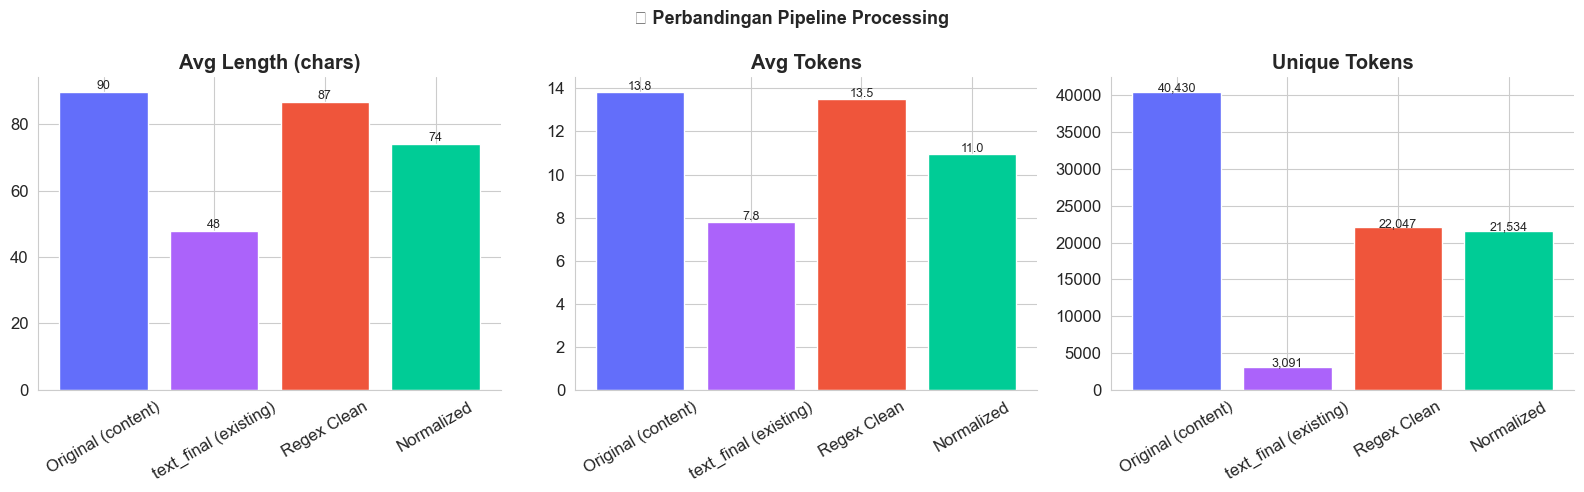

📌 Original (content)             → Reduksi: +0.0% dari original
📌 text_final (existing)          → Reduksi: +46.8% dari original
📌 Regex Clean                    → Reduksi: +3.3% dari original
📌 Normalized                     → Reduksi: +17.4% dari original


In [45]:
# ── Statistik per pipeline stage ──
stages = {
    'Original (content)': df_clean['content'].astype(str),
    'text_final (existing)': df_clean['text_final'].astype(str),
    'Regex Clean': df_clean['content_regex_clean'].astype(str),
    'Normalized': df_clean['content_normalized'].astype(str),
}

stats = []
for name, col in stages.items():
    stats.append({
        'Stage': name,
        'Avg Length': col.str.len().mean(),
        'Median Length': col.str.len().median(),
        'Avg Tokens': col.apply(lambda x: len(x.split())).mean(),
        'Empty Count': (col.str.strip() == '').sum(),
        'Unique Tokens': len(set(' '.join(col).split())),
    })

df_stats = pd.DataFrame(stats)
print("📊 Pipeline Processing Statistics")
display(df_stats.round(1))

# ── Grouped Bar Chart ──
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

colors = ['#636EFA', '#AB63FA', '#EF553B', '#00CC96']

axes[0].bar(df_stats['Stage'], df_stats['Avg Length'], color=colors)
axes[0].set_title('Avg Length (chars)', fontweight='bold')
axes[0].tick_params(axis='x', rotation=30)
axes[0].spines[['top', 'right']].set_visible(False)
for i, v in enumerate(df_stats['Avg Length']):
    axes[0].text(i, v + 1, f'{v:.0f}', ha='center', fontsize=9)

axes[1].bar(df_stats['Stage'], df_stats['Avg Tokens'], color=colors)
axes[1].set_title('Avg Tokens', fontweight='bold')
axes[1].tick_params(axis='x', rotation=30)
axes[1].spines[['top', 'right']].set_visible(False)
for i, v in enumerate(df_stats['Avg Tokens']):
    axes[1].text(i, v + 0.1, f'{v:.1f}', ha='center', fontsize=9)

axes[2].bar(df_stats['Stage'], df_stats['Unique Tokens'], color=colors)
axes[2].set_title('Unique Tokens', fontweight='bold')
axes[2].tick_params(axis='x', rotation=30)
axes[2].spines[['top', 'right']].set_visible(False)
for i, v in enumerate(df_stats['Unique Tokens']):
    axes[2].text(i, v + 100, f'{v:,}', ha='center', fontsize=9)

plt.suptitle('📊 Perbandingan Pipeline Processing', fontweight='bold', fontsize=13)
plt.tight_layout()
plt.show()

# ── Persentase perbaikan ──
orig_len = df_stats.iloc[0]['Avg Length']
for _, row in df_stats.iterrows():
    reduction = (1 - row['Avg Length'] / orig_len) * 100
    print(f"📌 {row['Stage']:30s} → Reduksi: {reduction:+.1f}% dari original")

## 20) ☁️ WordCloud & Top Kata Setelah Full Pipeline

Visualisasi akhir: WordCloud **sebelum** dan **sesudah** regex cleaning untuk melihat dampak preprocessing secara visual.

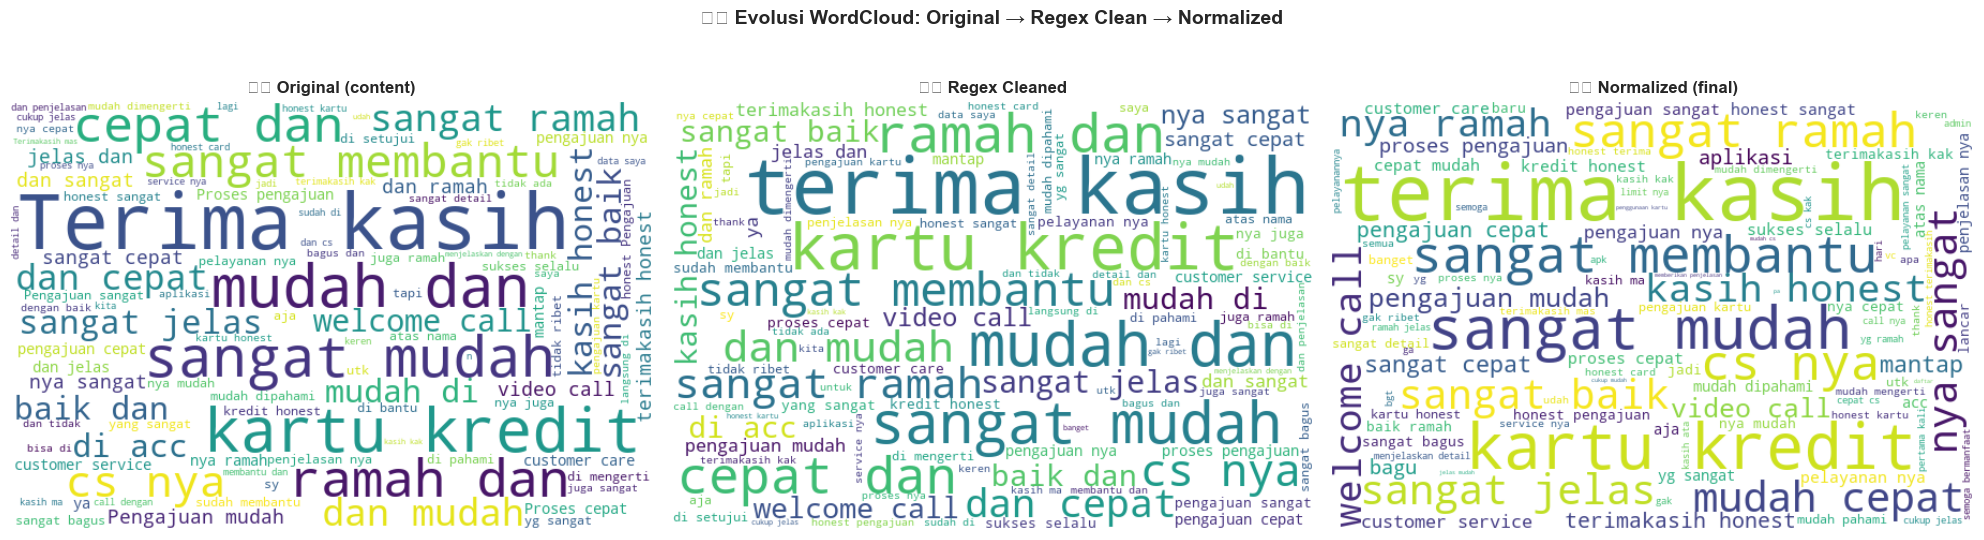

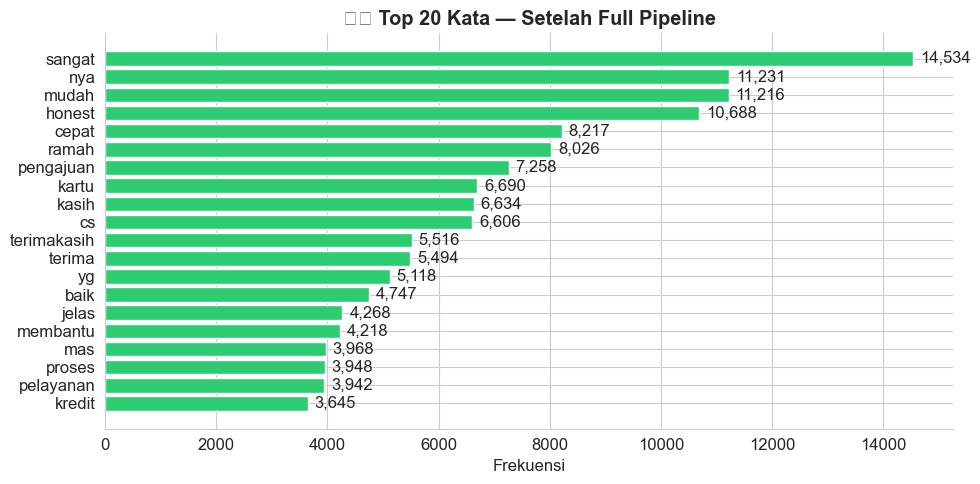

In [46]:
from wordcloud import WordCloud

# ── Gabung teks ──
text_original   = ' '.join(df_clean['content'].astype(str).tolist())
text_cleaned    = ' '.join(df_clean['content_regex_clean'].dropna().tolist())
text_normalized = ' '.join(df_clean['content_normalized'].dropna().tolist())

# ── WordCloud side-by-side ──
fig, axes = plt.subplots(1, 3, figsize=(20, 6))

wc_params = dict(width=600, height=400, background_color='white',
                 colormap='viridis', max_words=100)

wc_orig = WordCloud(**wc_params).generate(text_original)
axes[0].imshow(wc_orig, interpolation='bilinear')
axes[0].set_title('☁️ Original (content)', fontweight='bold', fontsize=12)
axes[0].axis('off')

wc_clean = WordCloud(**wc_params).generate(text_cleaned)
axes[1].imshow(wc_clean, interpolation='bilinear')
axes[1].set_title('☁️ Regex Cleaned', fontweight='bold', fontsize=12)
axes[1].axis('off')

wc_norm = WordCloud(**wc_params).generate(text_normalized)
axes[2].imshow(wc_norm, interpolation='bilinear')
axes[2].set_title('☁️ Normalized (final)', fontweight='bold', fontsize=12)
axes[2].axis('off')

plt.suptitle('☁️ Evolusi WordCloud: Original → Regex Clean → Normalized',
             fontweight='bold', fontsize=14)
plt.tight_layout()
plt.show()

# ── Top 20 kata setelah normalisasi ──
final_tokens = text_normalized.split()
top20_final = Counter(final_tokens).most_common(20)

fig, ax = plt.subplots(figsize=(10, 5))
words, counts = zip(*top20_final)
bars = ax.barh(list(reversed(words)), list(reversed(counts)), color='#2ecc71')
ax.bar_label(bars, fmt='{:,.0f}', padding=5)
ax.set_xlabel('Frekuensi')
ax.set_title('☁️ Top 20 Kata — Setelah Full Pipeline', fontweight='bold')
ax.spines[['top', 'right']].set_visible(False)
plt.tight_layout()
plt.show()

## 12) 💡 Insight & Temuan Utama

Berikut adalah rangkuman insight yang diperoleh dari EDA:

| No | Pertanyaan | Temuan |
|----|-----------|--------|
| Q1 | Bagaimana distribusi rating? | Score 5 mendominasi **87.9%** (34,018 dari 38,709 review). Rata-rata score **4.61**, median **5.0**. Dataset sangat positif-skewed. |
| Q2 | Apakah ada missing values? | Hanya kolom `reviewCreatedVersion` yang memiliki missing values: **5,063 baris (12.93%)**. Kolom lain lengkap. |
| Q3 | Apakah ada duplikasi? | Ditemukan **455 baris duplikat (~1.16%)**. Setelah dihapus, tersisa **38,709 baris** bersih. |
| Q4 | Bagaimana panjang review? | Review negatif (score 1) rata-rata **9.9 kata**, sedangkan positif (score 5) **7.6 kata**. Pengguna tidak puas cenderung menulis lebih detail. Content asli rata-rata **90 karakter**, text_final **48 karakter**. |
| Q5 | Versi mana paling banyak direview? | Versi **3.276.0** paling banyak dengan **926 review**. Versi **3.618.0** memiliki rata-rata score terendah (**4.20**) di antara top 15 versi. |
| Q6 | Seberapa efektif preprocessing? | Rata-rata reduksi teks **~43%** dari panjang asli. Distribusi reduksi mendekati normal, menunjukkan proses cleaning konsisten. |
| Q7 | Kata apa yang dominan? | Positif: **kasih, sangat, terima, mudah** (→ "terima kasih", layanan mudah). Negatif: **data, limit, kartu, tolak** (→ keluhan fitur kredit/limit). |
| Q8 | Bagaimana korelasi antar fitur? | `clean_len` ↔ `word_count` sangat kuat (**r=0.991**). Score hanya berkorelasi lemah negatif dengan panjang review (**r≈-0.11**). |

## ✅ Kesimpulan

Berdasarkan analisis EDA terhadap **38,709 review** aplikasi Honest (setelah deduplikasi):

1. **Distribusi Rating Sangat Positif** — Score 5 mendominasi **87.9%** review (34,018 dari 38,709). Rata-rata score **4.61**, menunjukkan tingkat kepuasan pengguna yang sangat tinggi.

2. **Missing Values Terkontrol** — Hanya kolom `reviewCreatedVersion` yang memiliki nilai kosong (**5,063 baris / 12.93%**), kemungkinan karena pengguna tidak mengupdate versi aplikasi. Kolom utama (`score`, `content`, `text_final`) lengkap 100%.

3. **Review Negatif Lebih Detail** — Pengguna dengan score rendah (1-2) menulis rata-rata **9.5–9.9 kata**, sedangkan pengguna score 5 hanya **7.6 kata**. Ini konsisten dengan pola umum: keluhan membutuhkan penjelasan lebih panjang.

4. **Preprocessing Efektif** — Cleaning dan stemming mereduksi panjang teks rata-rata **~43%**, dari 90 karakter menjadi 48 karakter. Distribusi reduksi mendekati normal (konsisten).

5. **Kata Kunci Sentimen Jelas** — Review positif didominasi kata *kasih, sangat, terima, mudah* (ungkapan terima kasih & kemudahan). Review negatif berisi *data, limit, kartu, tolak* (keluhan terkait fitur kredit, limit, dan penolakan).

6. **Versi 3.618.0 Perlu Perhatian** — Di antara 15 versi teratas, versi ini memiliki rata-rata score terendah (**4.20**), menunjukkan kemungkinan ada regresi atau bug yang memengaruhi kepuasan pengguna.

7. **Regex Cleaning Tambahan** — `re.sub()` membersihkan karakter non-alfanumerik menghasilkan reduksi rata-rata **~3.1%** tambahan di atas preprocessing awal, membuktikan masih ada noise residual pasca-stemming.

8. **Deteksi Keluhan via Regex** — Pattern matching mengidentifikasi **6 kategori keluhan utama**: UI/UX mendominasi (2,725 review), diikuti Lambat (669), Fitur Hilang (583), Login (385), Bug (288), dan Iklan (157).

9. **Ekstraksi Entitas dengan Named Groups** — `(?P<name>...)` berhasil mendeteksi **720 angka**, **284 referensi uang**, **56 tanggal**, dan **1,630 domain** — data terstruktur yang tersembunyi dalam teks review.

10. **Pipeline 4-Tahap** — Perbandingan Original → Regex Clean → Stopword Removal → Normalisasi menunjukkan pengurangan panjang teks bertahap, dengan normalisasi memberikan reduksi tambahan **14.6%** dan median akhir **60 karakter**.

---